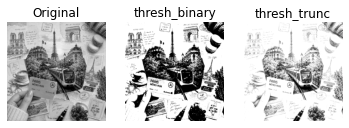

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('image.jpg', 0)

ret, thresh_binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
ret, thresh_trunc = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)


plt.subplot(1, 3, 1)
plt.imshow(img , cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(thresh_binary , cmap="gray")
plt.title("thresh_binary")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(thresh_trunc , cmap="gray")
plt.title("thresh_trunc")
plt.axis("off")


plt.show()

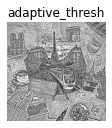

In [26]:
adaptive_thresh = cv2.adaptiveThreshold(img, 255, 
cv2.ADAPTIVE_THRESH_MEAN_C,
cv2.THRESH_BINARY, 11, 2)

plt.subplot(1, 3, 1)
plt.imshow(adaptive_thresh , cmap="gray")
plt.title("adaptive_thresh")
plt.axis("off")

plt.show()

Optimal Threshold found by Otsu: 130.0


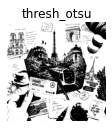

In [32]:

ret_otsu, thresh_otsu = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
print(f"Optimal Threshold found by Otsu: {ret_otsu}")

plt.subplot(1, 3, 1)
plt.imshow(thresh_otsu,cmap="gray" )
plt.title("thresh_otsu")
plt.axis("off")
plt.show()

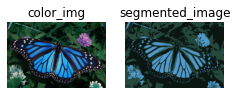

In [39]:
color_img = cv2.imread('monarch.jpg')
img_gray = cv2.cvtColor(color_img, cv2.COLOR_BGR2RGB)
pixel_values = color_img.reshape((-1, 3))

pixel_values = np.float32(pixel_values)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3 

ret, labels, centers = cv2.kmeans(pixel_values, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)

centers = np.uint8(centers)

segmented_data = centers[labels.flatten()]

segmented_image = segmented_data.reshape((color_img.shape))

plt.subplot(1, 3, 1)
plt.imshow(color_img  )
plt.title("color_img")
plt.axis("off")


plt.subplot(1, 3, 2)
plt.imshow(segmented_image )
plt.title("segmented_image")
plt.axis("off")

plt.show()